In [6]:
import clip
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data.dataloader import DataLoader
from tqdm import tqdm

from ca_sae.sae.batch_top_k import BatchTopKSAE
from ca_sae.sae.softsae import SoftSAE
from ca_sae.sae.ca_sae import ClassAlignedSAE

In [7]:
clip_model, clip_preprocess = clip.load("ViT-L/14")

In [8]:
def transform(batch):
    batch["pixel_values"] = [
        clip_preprocess(image.convert("RGB"))
        for image in batch["image"]
    ]
    del batch['image']
    return batch



imagenet100 = load_dataset(
    "clane9/imagenet-100", cache_dir="../hf_cache", split="validation"
)
imagenet100.set_transform(transform)

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

In [9]:
dataloader = DataLoader(imagenet100, batch_size=64)

In [10]:
# sae = SoftSAE.from_pretrained("../checkpoints/test/rework_v1_basic_l0/ae.pt").cuda()
# sae = SoftSAE.from_pretrained("../checkpoints/test/SoftSAE_4096_64/ae.pt").cuda()
# sae = SoftSAE.from_pretrained("../checkpoints/test/rework_v1_gradient_trick/ae.pt").cuda()
# sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_v1/ae.pt", features_per_class=5).cuda()
# sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_v2").cuda()
sae = ClassAlignedSAE.from_pretrained("../checkpoints/test/ca_sae_tight_l0_agr/").cuda()
# sae = BatchTopKSAE.from_pretrained("../checkpoints/test/BatchTopKSAESecond/ae.pt").cuda()
sae = sae.eval()

In [11]:
clip_embeddings= []
sae_embeddings = []
labels = []

with torch.inference_mode():
    for batch in tqdm(dataloader):
        images = batch['pixel_values'].cuda()
        labels_batch = batch['label']

        clip_out = clip_model.encode_image(images)
        sae_out = sae.encode(clip_out)

        clip_embeddings.append(clip_out)
        sae_embeddings.append(sae_out)
        labels.append(labels_batch)
        

100%|██████████| 79/79 [00:53<00:00,  1.47it/s]


In [12]:
clip_embeddings = torch.cat(clip_embeddings)
sae_embeddings = torch.cat(sae_embeddings)
labels = torch.cat(labels)

# K Distribution

(array([5.64971605e-05, 6.77965926e-04, 1.12994321e-03, 4.12429272e-03,
        4.80226899e-03, 9.54802013e-03, 1.00564946e-02, 1.46892617e-02,
        1.30508441e-02, 2.02824806e-02, 1.54802220e-02, 1.98305461e-02,
        1.77965672e-02, 1.37288396e-02, 1.84180743e-02, 1.28248554e-02,
        1.57627078e-02, 1.05649690e-02, 1.43502788e-02, 9.09604285e-03,
        1.22599103e-02, 7.11862688e-03, 6.94916572e-03, 5.48023638e-03,
        5.42371572e-03, 4.18078087e-03, 2.20339401e-03, 2.76836683e-03,
        1.97739636e-03, 2.09039944e-03, 1.18644293e-03, 8.47455582e-04,
        9.03952620e-04, 9.03956517e-04, 6.21470105e-04, 5.08473349e-04,
        3.38983694e-04, 1.69491116e-04, 5.64972823e-05, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 5.64970388e-05, 0.00000000e+00,
        5.64970388e-05, 0.00000000e+00, 0.00000000e+00, 5.64972823e-05,
        0.00000000e+00, 5.64970388e-05]),
 array([ 60.        ,  63.54000092,  67.08000183,  70.62000275,
         74.16000366,  77.6999

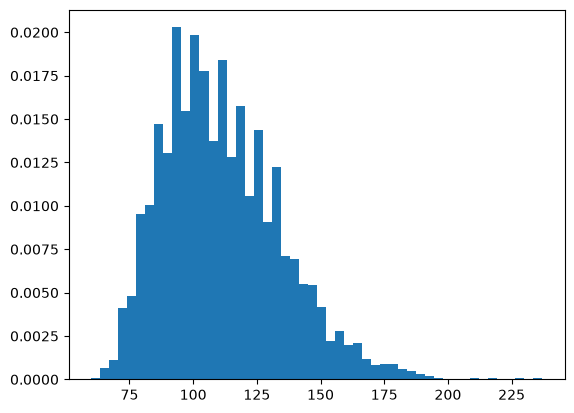

In [13]:
ks = (sae_embeddings !=  0).float().sum(dim=-1).cpu().numpy()

plt.hist(ks, bins=50, density=True)

# Feature examinationn

In [14]:
print("Dead features:",   torch.all(sae_embeddings == 0, dim=0).sum().item())

Dead features: 3


In [15]:
preview_ds = load_dataset(
    "clane9/imagenet-100", cache_dir="../hf_cache", split="validation"
)

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

In [34]:
row, col = torch.unravel_index(sae_embeddings.argmax(), sae_embeddings.shape)

examples_ = sae_embeddings[:, 1].topk(10)
print(examples_.values)
examples  = examples_.indices[examples_.values.nonzero()]
examples
col

tensor([0.6833, 0.5975, 0.5612, 0.5449, 0.4846, 0.4816, 0.4670, 0.4658, 0.4545,
        0.4529], device='cuda:0')


tensor(3919, device='cuda:0')

In [22]:
sae_embeddings.mean(dim=0).topk(10).indices

tensor([3919,  188, 4020, 2582, 2965, 2290, 2501, 2147, 3375, 2844],
       device='cuda:0')

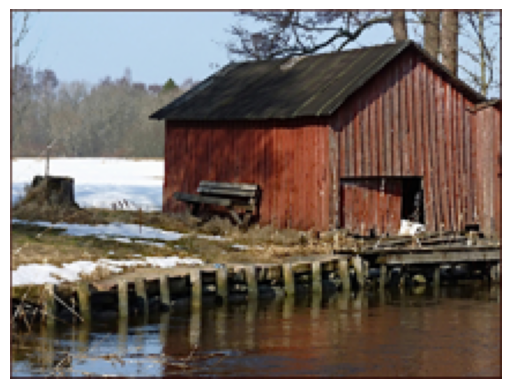

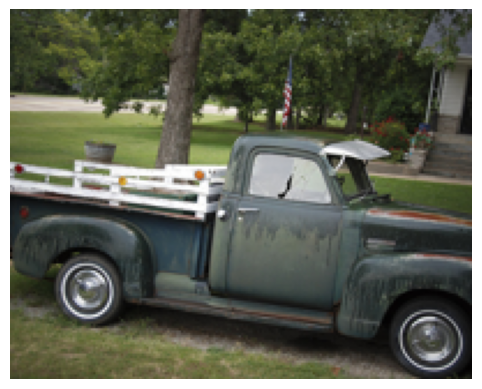

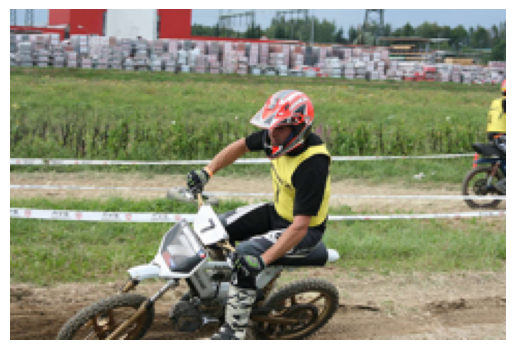

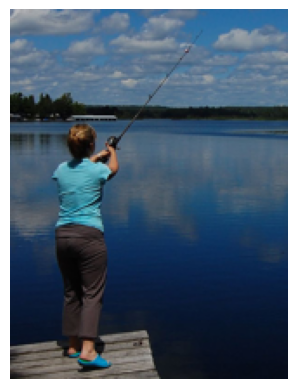

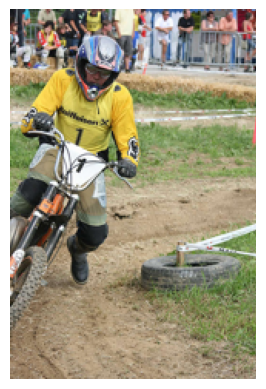

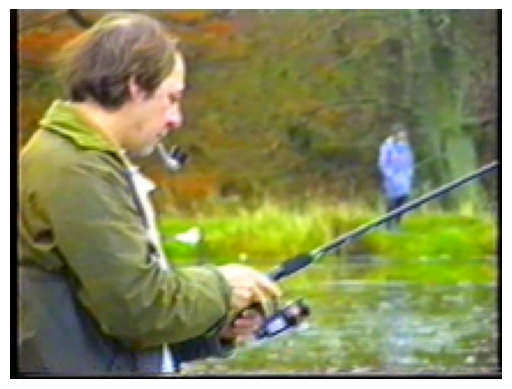

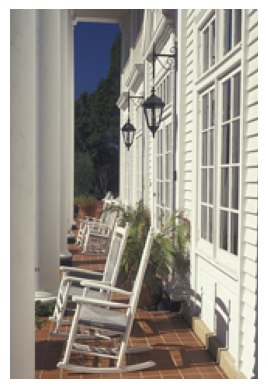

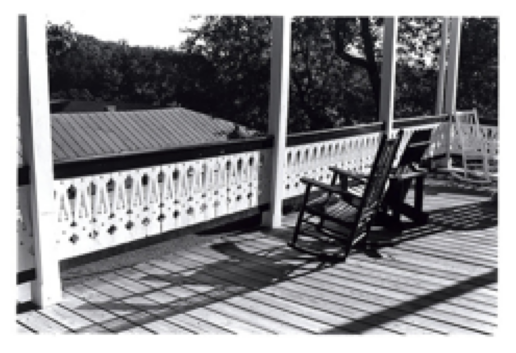

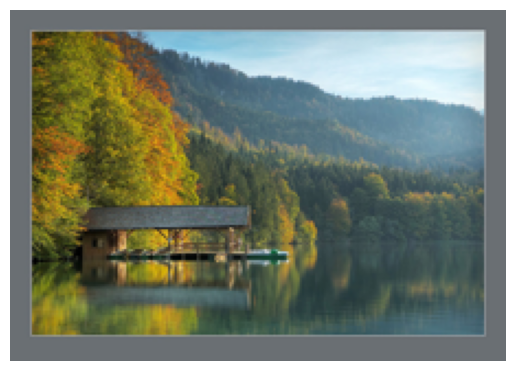

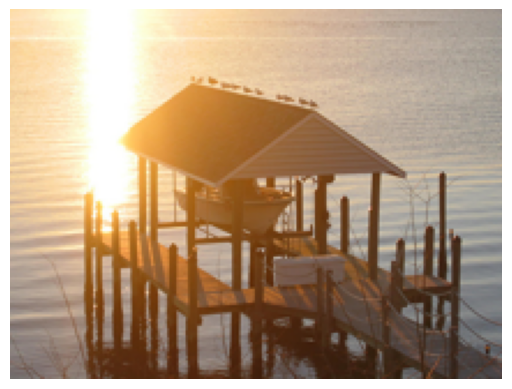

In [35]:
for e in examples:
    plt.axis('off')
    plt.imshow(preview_ds[e.item()]['image'])
    plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(clip_embeddings.clone().cpu().numpy(), labels.clone().cpu().numpy())

probe = LogisticRegression(max_iter=1000)

probe.fit(X_train, y_train)

y_pred = probe.predict(X_test)
accuracy_score(y_test, y_pred)

0.9424

In [20]:
X_train, X_test, y_train, y_test = train_test_split(sae_embeddings.clone().cpu().numpy(), labels.clone().cpu().numpy())

probe = LogisticRegression(max_iter=1000)

probe.fit(X_train, y_train)

y_pred = probe.predict(X_test)
accuracy_score(y_test, y_pred)

0.9264